In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!") 

Libraries imported successfully!


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd

df = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")

print("Dataset loaded successfully!")
print(df.shape)

Dataset loaded successfully!
(4340, 8)


In [4]:
print(df.columns)
df.head()

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='object')


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [6]:
print(df.isnull().sum())
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

print(pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
}))


name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64
               Missing Values  Percentage
name                        0         0.0
year                        0         0.0
selling_price               0         0.0
km_driven                   0         0.0
fuel                        0         0.0
seller_type                 0         0.0
transmission                0         0.0
owner                       0         0.0


In [7]:
print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 763
Duplicates after: 0


In [8]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print(df.columns)

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='object')


In [9]:
print(df.columns.tolist())

['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']


In [10]:
text_columns = ['name', 'fuel', 'seller_type', 'transmission', 'owner']

for col in text_columns:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

In [11]:
if 'fuel' in df.columns:
    df['fuel'] = df['fuel'].str.lower().str.strip()

print(df['fuel'].unique())

['petrol' 'diesel' 'cng' 'lpg' 'electric']


In [12]:
df['brand'] = df['name'].str.split().str[0]
print(df[['name','brand']].head(10))

                        name    brand
0              Maruti 800 AC   Maruti
1   Maruti Wagon R LXI Minor   Maruti
2       Hyundai Verna 1.6 SX  Hyundai
3     Datsun RediGO T Option   Datsun
4      Honda Amaze VX i-DTEC    Honda
5       Maruti Alto LX BSIII   Maruti
6  Hyundai Xcent 1.2 Kappa S  Hyundai
7   Tata Indigo Grand Petrol     Tata
8   Hyundai Creta 1.6 VTVT S  Hyundai
9   Maruti Celerio Green VXI   Maruti


In [13]:
CURRENT_YEAR = 2026
df['car_age'] = CURRENT_YEAR - df['year']
print(df[['year','car_age']].head())

   year  car_age
0  2007       19
1  2007       19
2  2012       14
3  2017        9
4  2014       12


In [14]:
df = df[df['car_age'] >= 0]
print("Dataset shape:", df.shape)

Dataset shape: (3577, 10)


In [15]:
print(df['selling_price'].describe())

count    3.577000e+03
mean     4.739125e+05
std      5.093018e+05
min      2.000000e+04
25%      2.000000e+05
50%      3.500000e+05
75%      6.000000e+05
max      8.900000e+06
Name: selling_price, dtype: float64


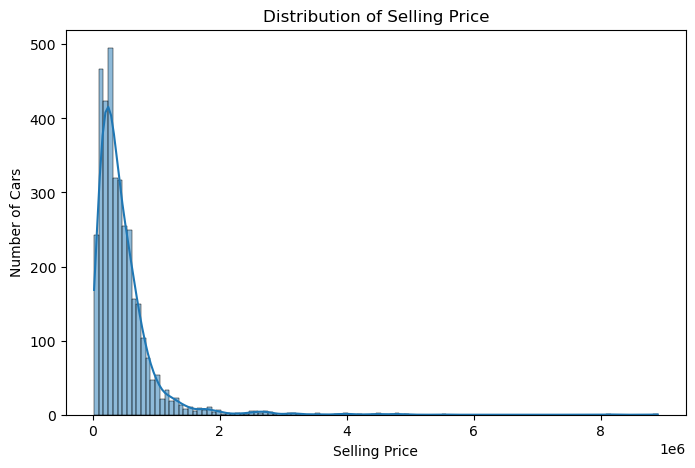

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df['selling_price'], kde=True)

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")

plt.show()

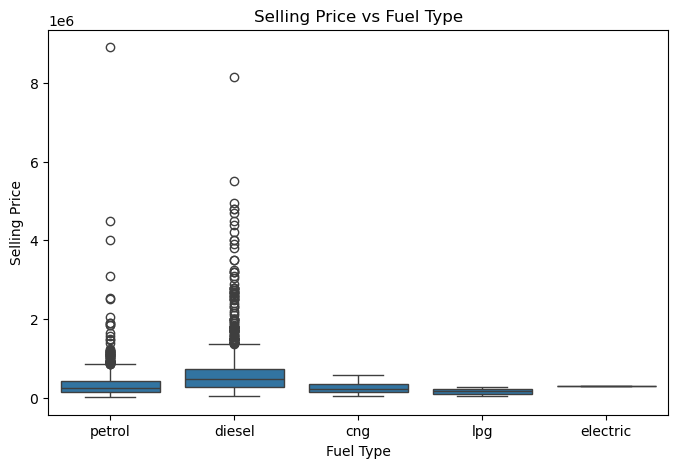

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='fuel', y='selling_price')

plt.title("Selling Price vs Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")

plt.show()

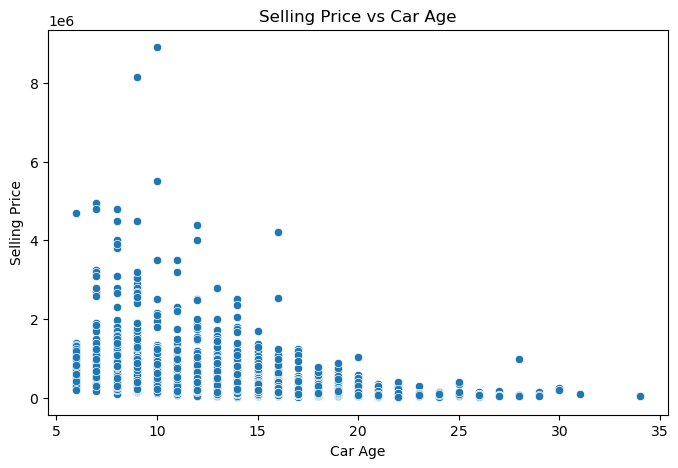

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='car_age',
    y='selling_price'
)

plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")

plt.show()

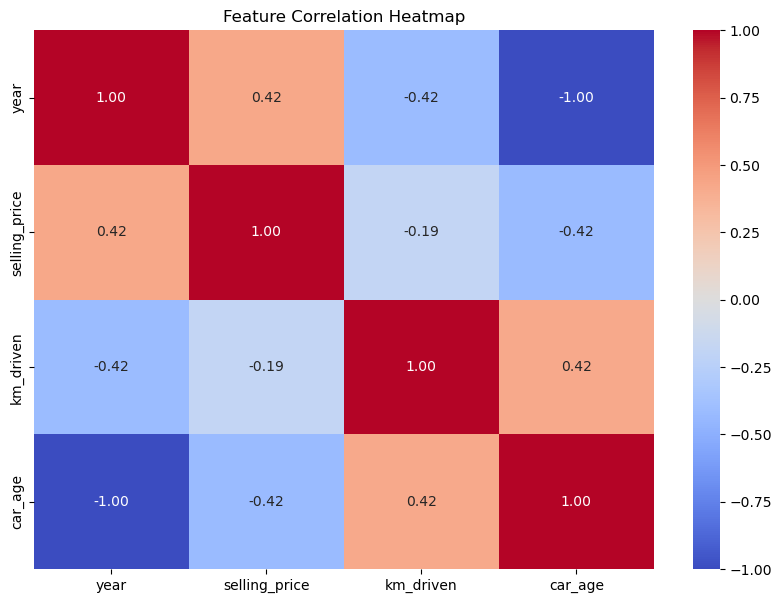

In [19]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [20]:
features = [
    'year',
    'km_driven',
    'fuel',
    'seller_type',
    'transmission',
    'owner',
    'brand',
    'car_age'
]

target = 'selling_price'

X = df[features]
y = df[target]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   year  km_driven    fuel seller_type transmission         owner    brand  \
0  2007      70000  petrol  Individual       Manual   First Owner   Maruti   
1  2007      50000  petrol  Individual       Manual   First Owner   Maruti   
2  2012     100000  diesel  Individual       Manual   First Owner  Hyundai   
3  2017      46000  petrol  Individual       Manual   First Owner   Datsun   
4  2014     141000  diesel  Individual       Manual  Second Owner    Honda   

   car_age  
0       19  
1       19  
2       14  
3        9  
4       12  

Target:
0     60000
1    135000
2    600000
3    250000
4    450000
Name: selling_price, dtype: int64


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2861, 8)
Testing data: (716, 8)


In [22]:
categorical_features = [
    'fuel',
    'seller_type',
    'transmission',
    'owner',
    'brand'
]

numeric_features = [
    'year',
    'km_driven',
    'car_age'
]

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)

In [24]:
linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [25]:
y_pred_linear = linear_model.predict(X_test)

print(y_pred_linear[:10])

[ 463650.82697394  473465.7326248   802415.70726885 1672448.24217923
  106340.63951906  378485.07871208  130954.19273808  671827.98827173
  822250.02596598  368604.11518912]


In [26]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("-------------------------")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R2 Score:", r2_linear)

Linear Regression
-------------------------
MAE : 206391.03087499193
RMSE: 431742.0185374333
R2 Score: 0.421354020104183


In [29]:
random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            RandomForestRegressor(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [30]:
y_pred_rf = random_forest_model.predict(X_test)

print(y_pred_rf[:10])

[ 578831.64772727  470540.42016667 1470114.909      2598020.81833333
  238341.66166667  346294.56892857  184937.5         678707.60666667
  879358.41857143  476515.        ]


In [31]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("-------------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest
-------------------------
MAE : 158549.9183129284
RMSE: 364050.63764491375
R2 Score: 0.5885776343275856


In [32]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest'
    ],
    'MAE': [
        mae_linear,
        mae_rf
    ],
    'RMSE': [
        rmse_linear,
        rmse_rf
    ],
    'R2 Score': [
        r2_linear,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,206391.030875,431742.018537,0.421354
1,Random Forest,158549.918313,364050.637645,0.588578


In [33]:
best_model_name = results.loc[
    results['R2 Score'].idxmax(),
    'Model'
]

print("Best Performing Model:", best_model_name)

Best Performing Model: Random Forest


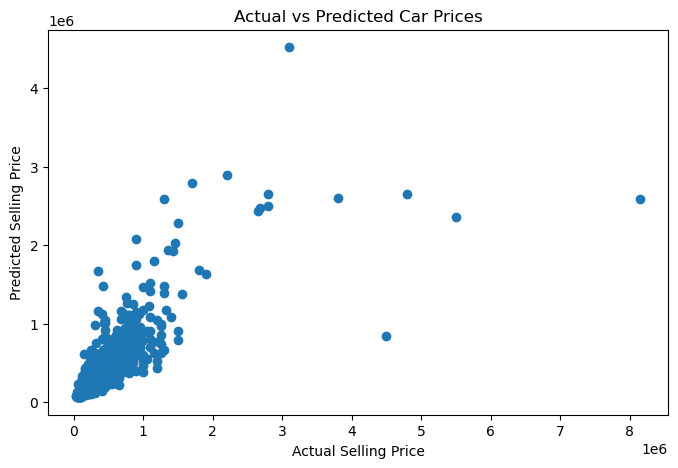

In [34]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

In [35]:
rf = random_forest_model.named_steps['model']

feature_names = (
    random_forest_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
8,categorical__transmission_Manual,0.131045
42,remainder__km_driven,0.130808
7,categorical__transmission_Automatic,0.116533
41,remainder__year,0.115924
43,remainder__car_age,0.111378
1,categorical__fuel_diesel,0.073013
15,categorical__brand_Audi,0.048269
3,categorical__fuel_petrol,0.043040
27,categorical__brand_Land,0.039996
38,categorical__brand_Toyota,0.036894


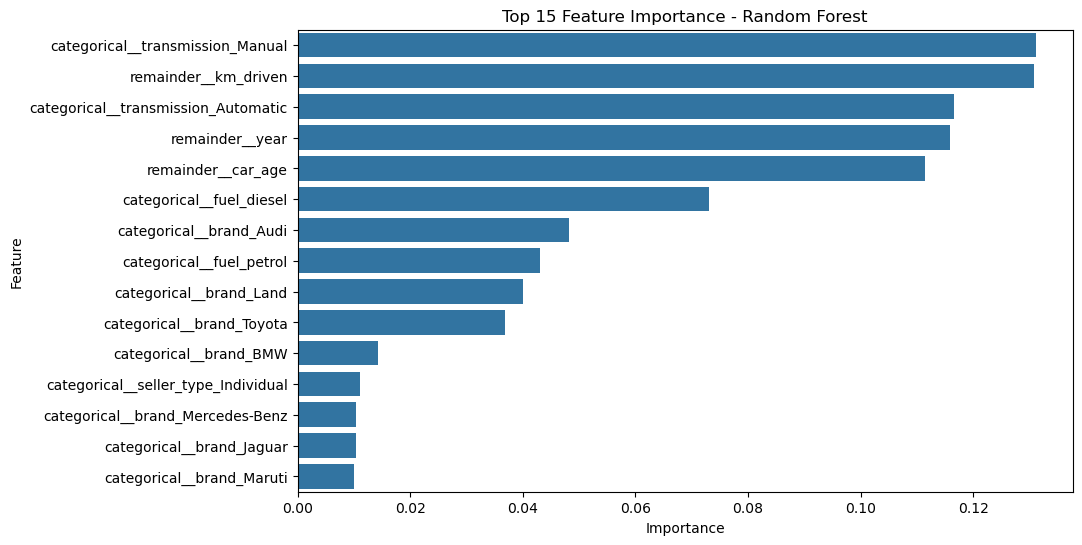

In [36]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title("Top 15 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [37]:
new_car = pd.DataFrame({
    'year': [2020],
    'km_driven': [30000],
    'fuel': ['petrol'],
    'seller_type': ['individual'],
    'transmission': ['manual'],
    'owner': ['first owner'],
    'brand': ['Maruti'],
    'car_age': [2026 - 2020]
})

predicted_price = random_forest_model.predict(new_car)

print("Predicted Car Selling Price:", predicted_price[0])

Predicted Car Selling Price: 589738.6300000001
